# 05 — Gas network linepack and quality agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/05_gas_network_linepack_quality_agent.ipynb)

Forecast delivery pressure and gas-quality fronts across a network during source and demand changes.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** network volumes, pressures, source compositions, demand,
and delivery specifications. **Outputs:** linepack forecast, quality
arrival time, constraint alarms, and balancing actions.

Section inventory is screened as $M=\rho(P,T,z)V$; composition fronts
are advected with section residence-time delays.

Deep dive: [natural-gas linepack](../../fluidflow/natural_gas_pipeline_linepack.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
source_a = NORTHSTAR_GAS
source_b = {
    "methane": 0.760,
    "ethane": 0.060,
    "propane": 0.025,
    "CO2": 0.120,
    "nitrogen": 0.035,
}
state_a = flash_state(source_a, 70.0, 20.0)
state_b = flash_state(source_b, 70.0, 20.0)
properties = pd.DataFrame(
    [
        {"source": "A", "density_kg_m3": state_a["density_kg_m3"], "Z": state_a["z_factor"]},
        {"source": "B", "density_kg_m3": state_b["density_kg_m3"], "Z": state_b["z_factor"]},
    ]
)
display(properties)


,source,density_kg_m3,Z
0,A,77.484564,0.796129
1,B,73.492344,0.838299


In [4]:
time_h = np.arange(0.0, 30.01, 0.25)
source_b_fraction = 1.0 / (1.0 + np.exp(-(time_h - 5.0) / 0.7))
demand = 1.0 + 0.16 * (time_h >= 12.0) - 0.08 * (time_h >= 24.0)
delays_h = np.array([2.0, 6.0, 10.0])
volumes_m3 = np.array([1.5e5, 1.9e5, 1.6e5])
section_pressure = []
section_co2 = []
inventory = []
imbalance_integral = np.cumsum((demand - 1.03) * 0.25)

for index, delay in enumerate(delays_h):
    delayed_fraction = 1.0 / (1.0 + np.exp(-(time_h - 5.0 - delay) / 0.7))
    co2 = 0.015 * (1.0 - delayed_fraction) + 0.120 * delayed_fraction
    pressure = 73.0 - 2.8 * index - 1.55 * imbalance_integral
    pressure -= 1.1 * delayed_fraction
    z_mix = state_a["z_factor"] * (1.0 - delayed_fraction) + state_b["z_factor"] * delayed_fraction
    rho_mix = state_a["density_kg_m3"] * pressure / 70.0 * state_a["z_factor"] / z_mix
    section_pressure.append(pressure)
    section_co2.append(co2)
    inventory.append(rho_mix * volumes_m3[index])

pressure_array = np.vstack(section_pressure)
co2_array = np.vstack(section_co2)
total_linepack_t = np.vstack(inventory).sum(axis=0) / 1000.0
relative_density = 0.60 + 0.85 * co2_array[-1]
gross_heating_mj_sm3 = 42.5 * (1.0 - co2_array[-1])
wobbe = gross_heating_mj_sm3 / np.sqrt(relative_density)
network = pd.DataFrame(
    {
        "time_h": time_h,
        "delivery_pressure_bar": pressure_array[-1],
        "delivery_co2_mol_pct": 100.0 * co2_array[-1],
        "wobbe_mj_sm3": wobbe,
        "linepack_t": total_linepack_t,
    }
)
display(network.iloc[::20].tail())


,time_h,delivery_pressure_bar,delivery_co2_mol_pct,wobbe_mj_sm3,linepack_t
40,10.0,67.875756,1.508294,53.471449,38113.173280
60,15.0,66.753125,6.750000,48.879998,36625.181359
80,20.0,65.196494,11.991706,44.644276,35710.996769
100,25.0,64.343126,11.999993,44.637832,35262.322109
120,30.0,63.955625,12.000000,44.637827,35058.643977


In [5]:
network["pressure_alarm"] = network.delivery_pressure_bar < 65.0
network["quality_alarm"] = network.wobbe_mj_sm3 < 47.0
first_quality_alarm = network.loc[network.quality_alarm, "time_h"].min()
first_pressure_alarm = network.loc[network.pressure_alarm, "time_h"].min()
alarm_table = pd.DataFrame(
    {
        "constraint": ["Wobbe minimum", "delivery pressure minimum"],
        "first_alarm_h": [first_quality_alarm, first_pressure_alarm],
        "action": ["limit source B and pre-blend", "increase inlet nomination or shed demand"],
    }
)
display(alarm_table)


,constraint,first_alarm_h,action
0,Wobbe minimum,15.75,limit source B and pre-blend
1,delivery pressure minimum,21.00,increase inlet nomination or shed demand


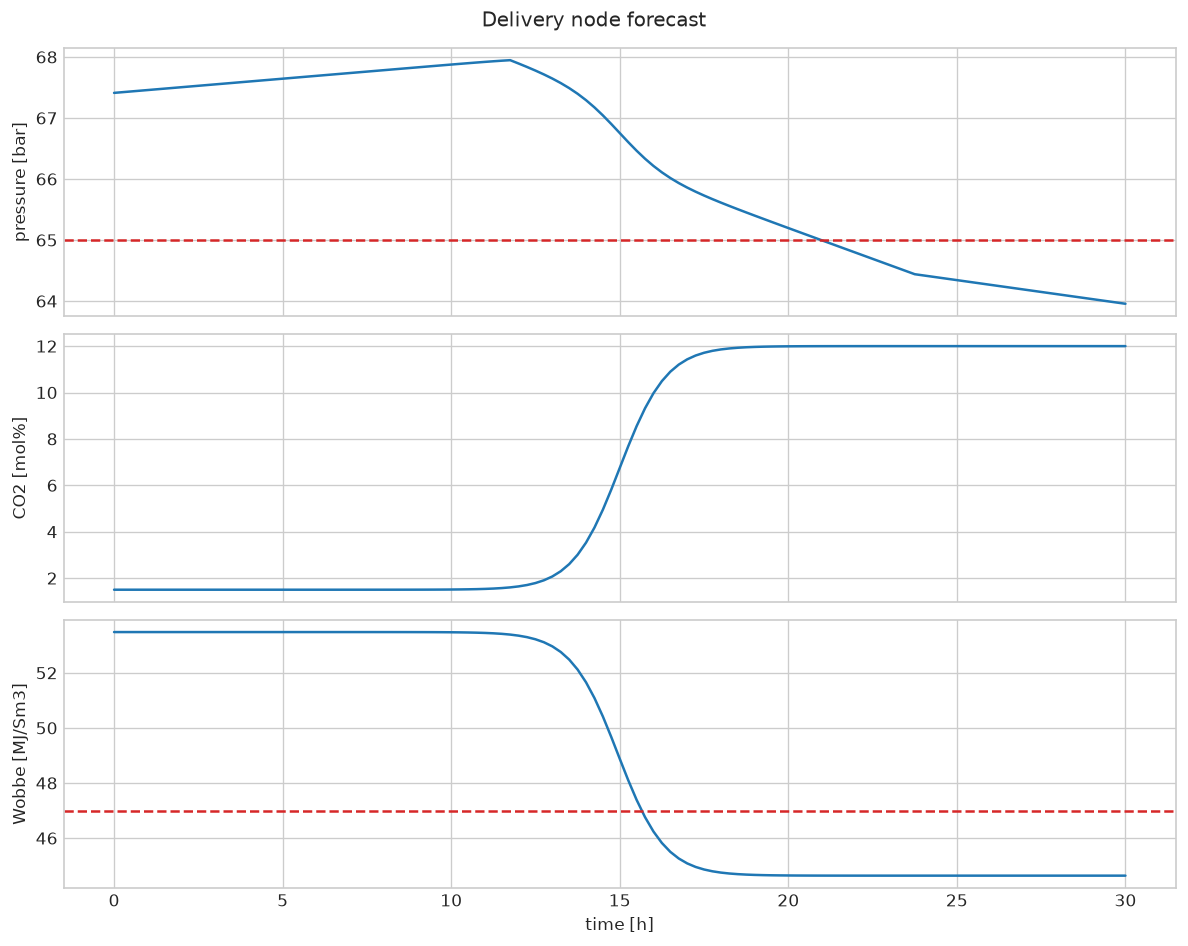

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(time_h, network.delivery_pressure_bar)
axes[0].axhline(65, color="tab:red", linestyle="--")
axes[1].plot(time_h, network.delivery_co2_mol_pct)
axes[2].plot(time_h, network.wobbe_mj_sm3)
axes[2].axhline(47, color="tab:red", linestyle="--")
axes[0].set_ylabel("pressure [bar]")
axes[1].set_ylabel("CO2 [mol%]")
axes[2].set_ylabel("Wobbe [MJ/Sm3]")
axes[2].set_xlabel("time [h]")
fig.suptitle("Delivery node forecast")
plt.tight_layout()
plt.show()


In [7]:
assert first_quality_alarm > 10.0
assert first_pressure_alarm > 12.0
assert network.linepack_t.max() > network.linepack_t.min()
print("VALIDATION PASSED")
print(f"Quality front alarm at {first_quality_alarm:.1f} h; act before arrival.")


VALIDATION PASSED
Quality front alarm at 15.8 h; act before arrival.


## Interpretation and limits

The quality front reaches the delivery node after the demand step,
followed by a pressure constraint. This reduced-order network is for
dispatch screening; validate with calibrated hydraulics, metering,
composition tracking, and contractual gas-quality calculations.
